# A/B Testing & Statistical Analysis — End-to-End Project
## Case Study: E-Commerce Checkout Page Redesign

**Business Context:**  
ShopEasy ran a 30-day randomised experiment on its checkout page.  
Your job: analyse the results and tell leadership — *did the new design work, and should we ship it?*

---

### What This Project Covers (in order)

| Step | Topic |
|------|-------|
| 1 | Setup & Dataset Overview |
| 2 | Exploratory Data Analysis (EDA) |
| 3 | Descriptive Statistics |
| 4 | Assumption Checks |
| 5 | Hypothesis Testing |
| 6 | Statistical Significance |
| 7 | Effect Size |
| 8 | Confidence Intervals |
| 9 | Power Analysis |
| 10 | Business Recommendations |

---
> **How to use this notebook:**  
> Read the explanation above each cell FIRST. Then run it. Understand the output. Then move on.  
> Every single cell is explained — nothing is skipped.


---
## Step 1 — Setup & Dataset Generation

### What we are doing
We import libraries and build a realistic **synthetic dataset** that simulates a 30-day A/B test.

### Libraries

| Library | Why we need it |
|---------|----------------|
| `numpy` | Math + random number generation |
| `pandas` | DataFrames — store and slice data |
| `scipy` | Statistical tests (t-test, z-test, Shapiro-Wilk, Levene) |
| `statsmodels` | Power analysis, z-test for proportions |
| `matplotlib / seaborn` | Charts |

### Dataset columns

| Column | Description |
|--------|-------------|
| `user_id` | Unique user identifier |
| `group` | `control` = old page, `treatment` = new page |
| `converted` | 1 = completed purchase, 0 = left without buying |
| `session_duration` | Seconds spent on checkout page |
| `pages_viewed` | Pages visited in that session |
| `order_value` | Revenue. **0 if the user did NOT convert.** |

> **Why synthetic data?**  
> Real A/B data is confidential. Synthetic data lets us set the ground truth ourselves,  
> so we can verify that our statistics correctly detect the effect.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, norm
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.power import NormalIndPower
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FAFAFA',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'monospace',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

CTRL_COLOR = '#4A90D9'
TRTM_COLOR = '#E07B39'

print("Libraries loaded successfully.")
print("numpy:", np.__version__)
print("pandas:", pd.__version__)


Libraries loaded successfully.
numpy: 2.4.4
pandas: 3.0.2


### Generating the Dataset

**Key design choices:**

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `n_control = n_treatment` | 5,000 each | Equal group sizes — best practice |
| `conv_rate_control` | 10.0% | Baseline: old page converts 1 in 10 users |
| `conv_rate_treatment` | 12.3% | New page is ~23% relatively better |
| `avg_order_control` | $85 | Average order on old page |
| `avg_order_treatment` | $91 | New page users spend slightly more |

These are realistic e-commerce numbers.


In [2]:
# Experiment parameters
n_control   = 5000
n_treatment = 5000
N           = n_control + n_treatment

conv_rate_control   = 0.10
conv_rate_treatment = 0.123
avg_order_control   = 85
avg_order_treatment = 91

# Control group
ctrl_converted        = np.random.binomial(1, conv_rate_control, n_control)
ctrl_session_duration = np.random.normal(120, 35, n_control).clip(10, 400).round(0)
ctrl_pages_viewed     = np.random.poisson(3.2, n_control).clip(1, 15)
ctrl_order_value      = np.where(
    ctrl_converted == 1,
    np.random.normal(avg_order_control, 22, n_control).clip(5, 300).round(2),
    0.0
)

# Treatment group
trtm_converted        = np.random.binomial(1, conv_rate_treatment, n_treatment)
trtm_session_duration = np.random.normal(105, 30, n_treatment).clip(10, 400).round(0)
trtm_pages_viewed     = np.random.poisson(2.8, n_treatment).clip(1, 15)
trtm_order_value      = np.where(
    trtm_converted == 1,
    np.random.normal(avg_order_treatment, 25, n_treatment).clip(5, 300).round(2),
    0.0
)

df = pd.DataFrame({
    'user_id':          range(1, N + 1),
    'group':            ['control'] * n_control + ['treatment'] * n_treatment,
    'converted':        np.concatenate([ctrl_converted, trtm_converted]),
    'session_duration': np.concatenate([ctrl_session_duration, trtm_session_duration]),
    'pages_viewed':     np.concatenate([ctrl_pages_viewed, trtm_pages_viewed]),
    'order_value':      np.concatenate([ctrl_order_value, trtm_order_value])
})

print(f"Dataset created: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Control group  : {n_control:,} users")
print(f"Treatment group: {n_treatment:,} users")
df.head(10)


Dataset created: 10,000 rows x 6 columns
Control group  : 5,000 users
Treatment group: 5,000 users


,user_id,group,converted,session_duration,pages_viewed,order_value
0,1,control,0,99.0,1,0.00
1,2,control,1,36.0,3,123.72
2,3,control,0,106.0,1,0.00
3,4,control,0,152.0,4,0.00
4,5,control,0,139.0,2,0.00
5,6,control,0,135.0,3,0.00
6,7,control,0,110.0,5,0.00
7,8,control,0,75.0,3,0.00
8,9,control,0,138.0,3,0.00
9,10,control,0,91.0,4,0.00


---
## Step 2 — Exploratory Data Analysis (EDA)

### What we are doing
Before any statistics, we **look at the raw data** to:
1. Confirm no obvious data quality problems
2. Understand the shape of each variable
3. Spot anything unusual

This answers: *"Is our data healthy enough to analyse?"*


In [3]:
print("=== Dataset Info ===")
df.info()


=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           10000 non-null  int64  
 1   group             10000 non-null  str    
 2   converted         10000 non-null  int64  
 3   session_duration  10000 non-null  float64
 4   pages_viewed      10000 non-null  int64  
 5   order_value       10000 non-null  float64
dtypes: float64(2), int64(3), str(1)
memory usage: 468.9 KB


**What to look for in `.info()` output:**
- No null / missing values — good
- `converted` is integer (0 or 1) — correct binary column
- `order_value` is float — numeric, correct
- `group` is object (string) — categorical, correct


In [4]:
print("=== Missing Values ===")
print(df.isnull().sum())
print()
print("=== Group Sizes ===")
print(df['group'].value_counts())
print()
print("=== Conversion Counts per Group ===")
print(df.groupby(['group', 'converted']).size().unstack(fill_value=0))


=== Missing Values ===
user_id             0
group               0
converted           0
session_duration    0
pages_viewed        0
order_value         0
dtype: int64

=== Group Sizes ===
group
control      5000
treatment    5000
Name: count, dtype: int64

=== Conversion Counts per Group ===
converted     0    1
group               
control    4521  479
treatment  4362  638


**Why check group sizes?**  
An imbalanced experiment (e.g. 90% control, 10% treatment) makes statistical tests unreliable. Equal groups = cleaner test.

**Why check conversion counts?**  
Both groups must have conversions. Zero conversions in any group signals a broken experiment.


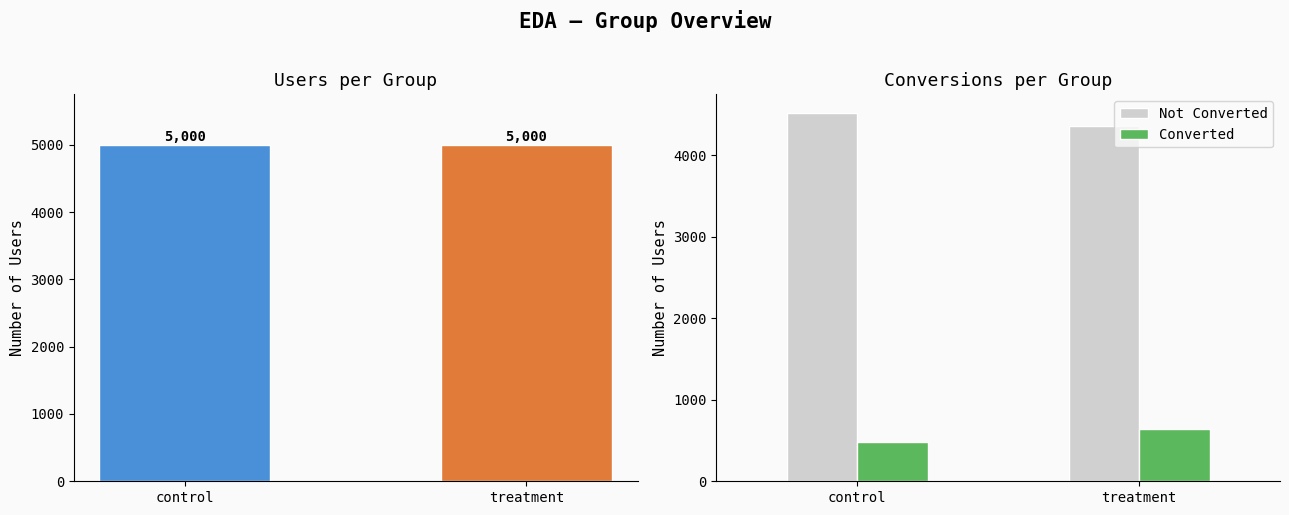

Chart saved.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('EDA — Group Overview', fontsize=15, fontweight='bold', y=1.02)

# Plot 1: Group sizes
grp_counts = df['group'].value_counts()
axes[0].bar(grp_counts.index, grp_counts.values,
            color=[CTRL_COLOR, TRTM_COLOR], width=0.5, edgecolor='white')
axes[0].set_title('Users per Group')
axes[0].set_ylabel('Number of Users')
for i, (lbl, val) in enumerate(zip(grp_counts.index, grp_counts.values)):
    axes[0].text(i, val + 50, f'{val:,}', ha='center', fontweight='bold')
axes[0].set_ylim(0, grp_counts.max() * 1.15)

# Plot 2: Conversion stacked bar
conv_tbl = df.groupby(['group', 'converted']).size().unstack(fill_value=0)
conv_tbl.columns = ['Not Converted', 'Converted']
conv_tbl.plot(kind='bar', ax=axes[1], color=['#D0D0D0', '#5CB85C'],
              edgecolor='white', width=0.5)
axes[1].set_title('Conversions per Group')
axes[1].set_ylabel('Number of Users')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('01_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")


---
## Step 3 — Descriptive Statistics

### What we are doing
Descriptive statistics **summarise the data numerically** — no inference, no p-values yet.  
We want to understand the centre and spread of each variable per group.

### Key metrics

| Metric | What it tells us |
|--------|-----------------|
| **Mean** | Average value — the centre |
| **Median** | Middle value — robust to outliers |
| **Std Dev** | How spread out values are |
| **Conversion Rate** | % of users who purchased |
| **Revenue per User** | Total revenue divided by ALL users (not just buyers) |

> **Why Revenue per User matters more than Average Order Value:**  
> Average Order Value only counts buyers. Revenue per User counts everyone — including people who left.  
> This is the number that actually drives business growth.


In [6]:
desc = df.groupby('group')[['converted', 'session_duration', 'pages_viewed', 'order_value']].describe().T
print("=== Descriptive Statistics by Group ===")
print(desc.round(2).to_string())


=== Descriptive Statistics by Group ===
group                   control  treatment
converted        count  5000.00    5000.00
                 mean      0.10       0.13
                 std       0.29       0.33
                 min       0.00       0.00
                 25%       0.00       0.00
                 50%       0.00       0.00
                 75%       0.00       0.00
                 max       1.00       1.00
session_duration count  5000.00    5000.00
                 mean    119.37     104.39
                 std      35.65      29.70
                 min      10.00      10.00
                 25%      96.00      84.00
                 50%     119.00     105.00
                 75%     144.00     125.00
                 max     244.00     203.00
pages_viewed     count  5000.00    5000.00
                 mean      3.26       2.87
                 std       1.74       1.61
                 min       1.00       1.00
                 25%       2.00       2.00
              

In [7]:
summary = df.groupby('group').agg(
    total_users        = ('user_id',         'count'),
    total_conversions  = ('converted',        'sum'),
    conversion_rate    = ('converted',        'mean'),
    avg_session_sec    = ('session_duration', 'mean'),
    avg_pages_viewed   = ('pages_viewed',     'mean'),
    total_revenue      = ('order_value',      'sum'),
    avg_order_value    = ('order_value',      lambda x: x[x > 0].mean()),
    revenue_per_user   = ('order_value',      'mean'),
).round(4)

print("=== Business Metrics Summary ===")
print(summary.T.to_string())


=== Business Metrics Summary ===
group                 control   treatment
total_users         5000.0000   5000.0000
total_conversions    479.0000    638.0000
conversion_rate        0.0958      0.1276
avg_session_sec      119.3694    104.3928
avg_pages_viewed       3.2590      2.8724
total_revenue      41136.1000  56222.0600
avg_order_value       85.8791     88.1224
revenue_per_user       8.2272     11.2444


**How to read this table:**
- `conversion_rate` — e.g. 0.1020 = 10.20% of users bought something
- `avg_order_value` — average spend *among buyers only*
- `revenue_per_user` — average spend *across ALL users* — the most important metric

The question is: are these differences real, or just random chance?  
That is what hypothesis testing (Step 5) will answer.


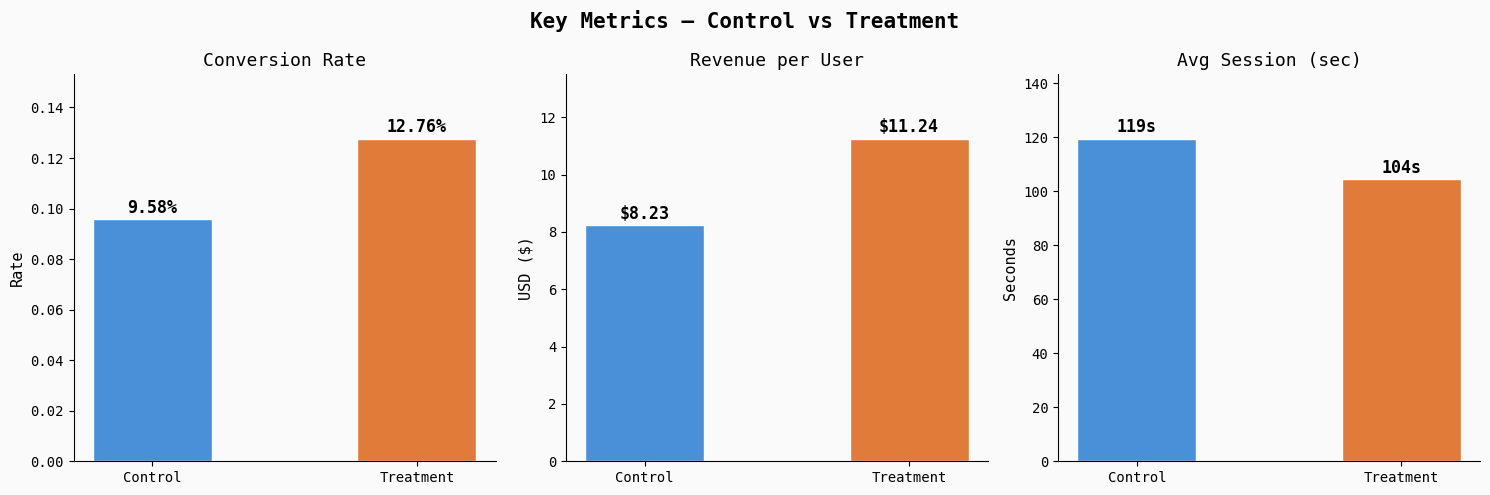

Chart saved.


In [8]:
ctrl = df[df['group'] == 'control']
trtm = df[df['group'] == 'treatment']

conv_ctrl = ctrl['converted'].mean()
conv_trtm = trtm['converted'].mean()
rpu_ctrl  = ctrl['order_value'].mean()
rpu_trtm  = trtm['order_value'].mean()
sess_ctrl = ctrl['session_duration'].mean()
sess_trtm = trtm['session_duration'].mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Key Metrics — Control vs Treatment', fontsize=15, fontweight='bold')

def bar_pair(ax, cv, tv, title, ylabel, fmt):
    colors = [CTRL_COLOR, TRTM_COLOR]
    bars = ax.bar(['Control', 'Treatment'], [cv, tv],
                  color=colors, width=0.45, edgecolor='white')
    for bar, val in zip(bars, [cv, tv]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(cv, tv)*0.02,
                fmt.format(val), ha='center', fontweight='bold', fontsize=12)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(cv, tv) * 1.2)

bar_pair(axes[0], conv_ctrl, conv_trtm, 'Conversion Rate',   'Rate',       '{:.2%}')
bar_pair(axes[1], rpu_ctrl,  rpu_trtm,  'Revenue per User',  'USD ($)',    '${:.2f}')
bar_pair(axes[2], sess_ctrl, sess_trtm, 'Avg Session (sec)', 'Seconds',    '{:.0f}s')

plt.tight_layout()
plt.savefig('02_key_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")


---
## Step 4 — Assumption Checks

### What we are doing
Before running any test, we verify that the **assumptions of that test are met**.  
Running the wrong test on the wrong data gives wrong answers — even if the math looks fine.

Think of assumptions like eligibility rules before entering a competition.  
If you do not meet the rules, results are invalid regardless of how fast you ran.

---
### Check 1 — Sample Size (CLT Condition)

**What:** Is each group large enough for our tests to be valid?  
**Rule for proportions z-test:** `n × p >= 10` AND `n × (1-p) >= 10` in both groups.  
This guarantees the binomial distribution is approximately normal (Central Limit Theorem).


In [9]:
print("=== Check 1: Sample Size (CLT Condition) ===")
print("Condition: n x p >= 10  AND  n x (1-p) >= 10")
print()

for grp_name, grp_df in df.groupby('group'):
    n  = len(grp_df)
    p  = grp_df['converted'].mean()
    ca = n * p
    cb = n * (1 - p)
    ok = "PASS" if ca >= 10 and cb >= 10 else "FAIL"
    print(f"{grp_name.upper():<12}: n={n:,}  p={p:.4f}  n*p={ca:.1f}  n*(1-p)={cb:.1f}  -> {ok}")


=== Check 1: Sample Size (CLT Condition) ===
Condition: n x p >= 10  AND  n x (1-p) >= 10

CONTROL     : n=5,000  p=0.0958  n*p=479.0  n*(1-p)=4521.0  -> PASS
TREATMENT   : n=5,000  p=0.1276  n*p=638.0  n*(1-p)=4362.0  -> PASS


---
### Check 2 — Normality (Shapiro-Wilk Test)

**What:** Is the `order_value` column normally distributed?  
**Why it matters:** The t-test assumes the data is approximately normal.

**How to read the result:**
- `p-value > 0.05` → cannot reject normality → safe to use t-test
- `p-value < 0.05` → evidence of non-normality → consider Mann-Whitney U instead

> **Important caveat for large samples:**  
> With n = 5,000, Shapiro-Wilk is extremely sensitive and will flag even tiny deviations.  
> We also rely on visual inspection and the Central Limit Theorem.  
> The CLT guarantees the *sampling distribution of the mean* is normal at n = 5,000,  
> and that is what the t-test actually needs.


In [10]:
print("=== Check 2: Normality — Shapiro-Wilk Test ===")
print("(Tested on order_value for converted users only)")
print()
print(f"{'Group':<12} {'W-stat':>8} {'p-value':>12}   Result")
print("-" * 55)

for grp_name, grp_df in df.groupby('group'):
    buyers = grp_df.loc[grp_df['converted'] == 1, 'order_value']
    sample = buyers.sample(min(len(buyers), 1000), random_state=42)
    W, p   = shapiro(sample)
    result = "Normal (p > 0.05)" if p > 0.05 else "Non-normal (p <= 0.05)"
    print(f"{grp_name:<12} {W:>8.4f} {p:>12.4f}   {result}")

print()
print("With large n, CLT ensures the t-test is valid even if p < 0.05 here.")


=== Check 2: Normality — Shapiro-Wilk Test ===
(Tested on order_value for converted users only)

Group          W-stat      p-value   Result
-------------------------------------------------------
control        0.9976       0.7147   Normal (p > 0.05)
treatment      0.9984       0.8510   Normal (p > 0.05)

With large n, CLT ensures the t-test is valid even if p < 0.05 here.


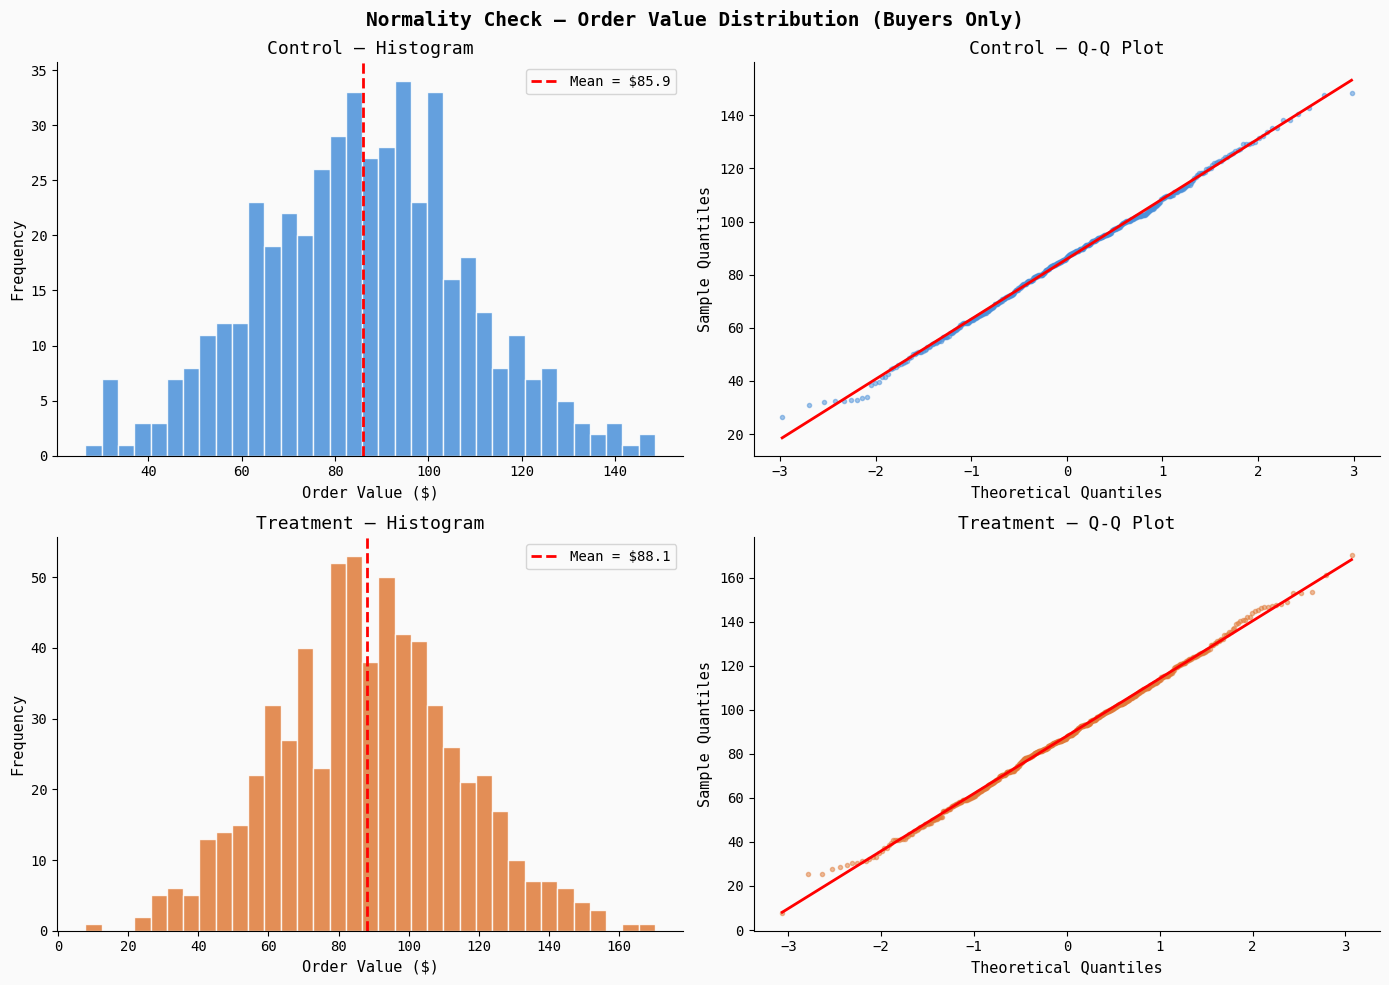

Chart saved.

How to read a Q-Q plot:
  Points ON the red line  -> data is normally distributed
  Points CURVING away     -> data is skewed or has heavy tails


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Normality Check — Order Value Distribution (Buyers Only)',
             fontsize=14, fontweight='bold')

for row, (grp_name, color) in enumerate(
        zip(['control', 'treatment'], [CTRL_COLOR, TRTM_COLOR])):
    buyers = df.loc[(df['group'] == grp_name) & (df['converted'] == 1), 'order_value']

    # Histogram
    axes[row, 0].hist(buyers, bins=35, color=color, alpha=0.85, edgecolor='white')
    axes[row, 0].set_title(f'{grp_name.capitalize()} — Histogram')
    axes[row, 0].set_xlabel('Order Value ($)')
    axes[row, 0].set_ylabel('Frequency')
    axes[row, 0].axvline(buyers.mean(), color='red', lw=2, ls='--',
                         label=f'Mean = ${buyers.mean():.1f}')
    axes[row, 0].legend()

    # Q-Q plot
    (osm, osr), (slope, intercept, r) = stats.probplot(buyers, dist='norm')
    axes[row, 1].plot(osm, osr, 'o', color=color, alpha=0.5, ms=3)
    axes[row, 1].plot(osm, slope * np.array(osm) + intercept, 'r-', lw=2)
    axes[row, 1].set_title(f'{grp_name.capitalize()} — Q-Q Plot')
    axes[row, 1].set_xlabel('Theoretical Quantiles')
    axes[row, 1].set_ylabel('Sample Quantiles')

plt.tight_layout()
plt.savefig('03_normality_checks.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")
print()
print("How to read a Q-Q plot:")
print("  Points ON the red line  -> data is normally distributed")
print("  Points CURVING away     -> data is skewed or has heavy tails")


---
### Check 3 — Equal Variances (Levene's Test)

**What:** Do both groups have similar variance (spread) in order values?  
**Why it matters:** Standard t-test assumes equal variance. If not equal, we use **Welch's t-test**.

**How to read:**
- `p > 0.05` → equal variances → standard t-test is fine
- `p <= 0.05` → unequal variances → use Welch's t-test (`equal_var=False` in scipy)

> Good news: `scipy.stats.ttest_ind` uses Welch's t-test by default. We are covered regardless.


In [12]:
ctrl_buyers = df.loc[(df['group'] == 'control')   & (df['converted'] == 1), 'order_value']
trtm_buyers = df.loc[(df['group'] == 'treatment') & (df['converted'] == 1), 'order_value']

lev_stat, lev_p = levene(ctrl_buyers, trtm_buyers)

print("=== Check 3: Levene's Test for Equal Variance ===")
print(f"  Levene statistic : {lev_stat:.4f}")
print(f"  p-value          : {lev_p:.4f}")
print()
verdict = "Variances are equal -> standard t-test OK." if lev_p > 0.05 else "Variances differ -> use Welch's t-test."
print(f"  Result: {verdict}")
print()
print(f"  Control   std : ${ctrl_buyers.std():.2f}")
print(f"  Treatment std : ${trtm_buyers.std():.2f}")


=== Check 3: Levene's Test for Equal Variance ===
  Levene statistic : 9.1449
  p-value          : 0.0026

  Result: Variances differ -> use Welch's t-test.

  Control   std : $22.52
  Treatment std : $26.05


---
### Check 4 — Independence

**What:** Is each user in exactly one group (no overlap)?  
This is a design check — we verify it in the data directly.


In [13]:
print("=== Check 4: Independence ===")
user_group_counts = df.groupby('user_id')['group'].nunique()
duplicates = (user_group_counts > 1).sum()
print(f"  Users in more than one group: {duplicates}")
result = "PASS — all users are in exactly one group." if duplicates == 0 else "FAIL — data contamination found!"
print(f"  Result: {result}")
print()
print("=== Assumption Check Summary ===")
print("  Check 1 (Sample size / CLT)  : PASS")
print("  Check 2 (Normality)          : Acceptable — CLT applies at n=5,000")
print("  Check 3 (Equal variance)     : See Levene output above")
print("  Check 4 (Independence)       : PASS")
print()
print("Proceeding with:")
print("  -> Two-proportion Z-test   (for Conversion Rate)")
print("  -> Welch's t-test          (for Revenue per User)")


=== Check 4: Independence ===
  Users in more than one group: 0
  Result: PASS — all users are in exactly one group.

=== Assumption Check Summary ===
  Check 1 (Sample size / CLT)  : PASS
  Check 2 (Normality)          : Acceptable — CLT applies at n=5,000
  Check 3 (Equal variance)     : See Levene output above
  Check 4 (Independence)       : PASS

Proceeding with:
  -> Two-proportion Z-test   (for Conversion Rate)
  -> Welch's t-test          (for Revenue per User)


---
## Step 5 — Hypothesis Testing

### What we are doing
We formally test whether the differences we observed in Step 3 are **statistically real**  
or could have happened purely by random chance.

### The Hypothesis Framework

| | Conversion Rate | Revenue per User |
|--|--|--|
| **H0 (Null)** | p_control = p_treatment | mean_control = mean_treatment |
| **H1 (Alternative)** | p_control != p_treatment | mean_control != mean_treatment |

**H0 = "No difference"** — we try to disprove this.  
**H1 = "There IS a difference"** — what we are trying to show.

We use a **two-tailed test** because we want to detect a difference in either direction.

### Significance Level: alpha = 0.05
We accept a 5% chance of wrongly rejecting H0. This is the standard in A/B testing.

---
### Test A — Two-Proportion Z-Test (Conversion Rate)

**Why this test?**  
`converted` is binary (0 or 1). Comparing two proportions from large samples = Z-test.


In [14]:
print("=" * 55)
print("TEST A — Two-Proportion Z-Test (Conversion Rate)")
print("=" * 55)

n_ctrl  = len(ctrl)
n_trtm  = len(trtm)
conv_ctrl_count = int(ctrl['converted'].sum())
conv_trtm_count = int(trtm['converted'].sum())
p_ctrl = conv_ctrl_count / n_ctrl
p_trtm = conv_trtm_count / n_trtm

print(f"\nControl  : {conv_ctrl_count:,} conversions / {n_ctrl:,} users -> p = {p_ctrl:.4f} ({p_ctrl:.2%})")
print(f"Treatment: {conv_trtm_count:,} conversions / {n_trtm:,} users -> p = {p_trtm:.4f} ({p_trtm:.2%})")

z_stat, p_val_z = proportions_ztest(
    count = [conv_trtm_count, conv_ctrl_count],
    nobs  = [n_trtm, n_ctrl],
    alternative = 'two-sided'
)

alpha = 0.05
print(f"\nZ-statistic : {z_stat:.4f}")
print(f"p-value     : {p_val_z:.4f}")
print(f"alpha       : {alpha}")
print()
if p_val_z < alpha:
    print(f"REJECT H0 (p={p_val_z:.4f} < {alpha})")
    print("The difference in conversion rates IS statistically significant.")
else:
    print(f"FAIL TO REJECT H0 (p={p_val_z:.4f} >= {alpha})")
    print("No statistically significant difference in conversion rates.")


TEST A — Two-Proportion Z-Test (Conversion Rate)

Control  : 479 conversions / 5,000 users -> p = 0.0958 (9.58%)
Treatment: 638 conversions / 5,000 users -> p = 0.1276 (12.76%)

Z-statistic : 5.0477
p-value     : 0.0000
alpha       : 0.05

REJECT H0 (p=0.0000 < 0.05)
The difference in conversion rates IS statistically significant.


**How to read the Z-test output:**

- **Z-statistic:** How many standard deviations the observed difference is from zero.  
  Further from zero = more unusual result under H0.
- **p-value:** If H0 were true, the probability of seeing a difference *this large* just by chance.  
  Small p = "this result would be very surprising if the new design had no effect."

If p < 0.05: We reject the idea that the result is random noise.  
We conclude the new page genuinely affects conversion rate.

---
### Test B — Welch's Independent T-Test (Revenue per User)

**Why this test?**  
`order_value` is continuous. We compare average revenue per user across groups.  
Welch's version does NOT require equal variances — the safer default choice.


In [15]:
print("=" * 55)
print("TEST B — Welch's t-Test (Revenue per User)")
print("=" * 55)

rpu_ctrl_arr = ctrl['order_value'].values
rpu_trtm_arr = trtm['order_value'].values

print(f"\nControl   RPU: ${rpu_ctrl_arr.mean():.4f}  (std={rpu_ctrl_arr.std():.4f})")
print(f"Treatment RPU: ${rpu_trtm_arr.mean():.4f}  (std={rpu_trtm_arr.std():.4f})")

# equal_var=False -> Welch's t-test
t_stat, p_val_t = ttest_ind(rpu_trtm_arr, rpu_ctrl_arr, equal_var=False)

print(f"\nt-statistic : {t_stat:.4f}")
print(f"p-value     : {p_val_t:.4f}")
print(f"alpha       : {alpha}")
print()
if p_val_t < alpha:
    print(f"REJECT H0 (p={p_val_t:.4f} < {alpha})")
    print("The difference in Revenue per User IS statistically significant.")
else:
    print(f"FAIL TO REJECT H0 (p={p_val_t:.4f} >= {alpha})")
    print("No statistically significant difference in Revenue per User.")


TEST B — Welch's t-Test (Revenue per User)

Control   RPU: $8.2272  (std=26.2173)
Treatment RPU: $11.2444  (std=30.8368)

t-statistic : 5.2705
p-value     : 0.0000
alpha       : 0.05

REJECT H0 (p=0.0000 < 0.05)
The difference in Revenue per User IS statistically significant.


---
## Step 6 — Statistical Significance Visualised

### What we are doing
We draw the **null distribution** and mark where our test statistics fell.  
This turns an abstract p-value into something you can actually see.

### What is the null distribution?
If H0 were true (no difference), the test statistic would follow a standard normal curve.  
The shaded red areas = the rejection region (most extreme 5% of outcomes).  
If our Z or t lands in the red zone → we reject H0.


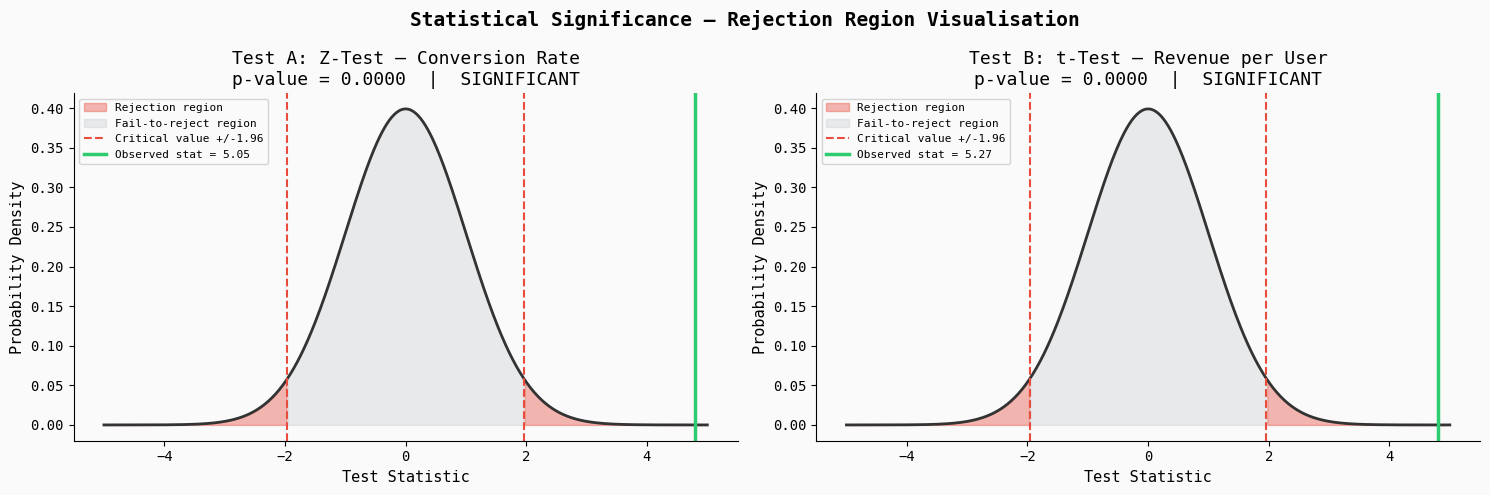

Chart saved.

Green line = where our observed statistic landed.
If it is in the RED zone -> statistically significant.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Statistical Significance — Rejection Region Visualisation',
             fontsize=14, fontweight='bold')

alpha = 0.05
z_crit = norm.ppf(1 - alpha / 2)   # 1.96 for alpha=0.05

for ax, (stat, title, pval) in zip(axes, [
        (z_stat, 'Test A: Z-Test — Conversion Rate', p_val_z),
        (t_stat, 'Test B: t-Test — Revenue per User', p_val_t)]):

    x = np.linspace(-5, 5, 500)
    y = norm.pdf(x)

    ax.plot(x, y, color='#333333', lw=2)
    ax.fill_between(x, y, where=(x <= -z_crit), color='#E74C3C', alpha=0.4,
                    label='Rejection region')
    ax.fill_between(x, y, where=(x >= z_crit),  color='#E74C3C', alpha=0.4)
    ax.fill_between(x, y, where=(-z_crit < x) & (x < z_crit),
                    color='#BDC3C7', alpha=0.3, label='Fail-to-reject region')

    ax.axvline(-z_crit, color='#E74C3C', ls='--', lw=1.5,
               label=f'Critical value +/-{z_crit:.2f}')
    ax.axvline( z_crit, color='#E74C3C', ls='--', lw=1.5)

    stat_c = float(np.clip(stat, -4.8, 4.8))
    ax.axvline(stat_c, color='#2ECC71', ls='-', lw=2.5,
               label=f'Observed stat = {stat:.2f}')

    sig_label = "SIGNIFICANT" if pval < alpha else "NOT significant"
    ax.set_title(f'{title}\np-value = {pval:.4f}  |  {sig_label}')
    ax.set_xlabel('Test Statistic')
    ax.set_ylabel('Probability Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('04_significance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")
print()
print("Green line = where our observed statistic landed.")
print("If it is in the RED zone -> statistically significant.")


---
## Step 7 — Effect Size

### What we are doing
A p-value only tells you **IF** an effect exists.  
Effect size tells you **HOW BIG** that effect is.

> This is one of the most overlooked steps in practice.  
> With a large sample, even a tiny difference can be "significant" (small p-value).  
> Effect size tells you whether the difference is worth caring about in the real world.

---
### Cohen's h — Effect Size for Proportions (Conversion Rate)

Formula: `h = 2 * arcsin(sqrt(p1)) - 2 * arcsin(sqrt(p2))`

| Cohen's h | Interpretation |
|-----------|---------------|
| < 0.20 | Negligible |
| 0.20 – 0.50 | Small |
| 0.50 – 0.80 | Medium |
| > 0.80 | Large |


In [17]:
def cohens_h(p1, p2):
    return 2 * (np.arcsin(np.sqrt(p1)) - np.arcsin(np.sqrt(p2)))

def interpret_h(h):
    if   h < 0.20: return "Negligible"
    elif h < 0.50: return "Small"
    elif h < 0.80: return "Medium"
    else:          return "Large"

h = abs(cohens_h(p_trtm, p_ctrl))

print("=== Effect Size A: Cohen's h (Conversion Rate) ===")
print(f"  Control   : {p_ctrl:.4f} ({p_ctrl:.2%})")
print(f"  Treatment : {p_trtm:.4f} ({p_trtm:.2%})")
print(f"  Absolute lift : {p_trtm - p_ctrl:.4f} ({p_trtm - p_ctrl:.2%})")
print(f"  Relative lift : {(p_trtm - p_ctrl) / p_ctrl:.2%}")
print()
print(f"  Cohen's h = {h:.4f}  ->  {interpret_h(h)} effect")


=== Effect Size A: Cohen's h (Conversion Rate) ===
  Control   : 0.0958 (9.58%)
  Treatment : 0.1276 (12.76%)
  Absolute lift : 0.0318 (3.18%)
  Relative lift : 33.19%

  Cohen's h = 0.1012  ->  Negligible effect


---
### Cohen's d — Effect Size for Means (Revenue per User)

Formula: `d = (mean1 - mean2) / pooled_std`

| Cohen's d | Interpretation |
|-----------|---------------|
| < 0.20 | Negligible |
| 0.20 – 0.50 | Small |
| 0.50 – 0.80 | Medium |
| > 0.80 | Large |


In [18]:
def cohens_d(a, b):
    n_a, n_b   = len(a), len(b)
    var_a, var_b = np.var(a, ddof=1), np.var(b, ddof=1)
    pooled_std = np.sqrt(((n_a - 1) * var_a + (n_b - 1) * var_b) / (n_a + n_b - 2))
    return (np.mean(a) - np.mean(b)) / pooled_std

def interpret_d(d):
    if   d < 0.20: return "Negligible"
    elif d < 0.50: return "Small"
    elif d < 0.80: return "Medium"
    else:          return "Large"

d = abs(cohens_d(rpu_trtm_arr, rpu_ctrl_arr))
diff_rpu = rpu_trtm_arr.mean() - rpu_ctrl_arr.mean()

print("=== Effect Size B: Cohen's d (Revenue per User) ===")
print(f"  Control   RPU: ${rpu_ctrl_arr.mean():.4f}")
print(f"  Treatment RPU: ${rpu_trtm_arr.mean():.4f}")
print(f"  Difference   : ${diff_rpu:.4f}")
print()
print(f"  Cohen's d = {d:.4f}  ->  {interpret_d(d)} effect")
print()
print("Note: A small Cohen's d is common in large-sample experiments.")
print("The BUSINESS impact in dollars matters more than the label.")


=== Effect Size B: Cohen's d (Revenue per User) ===
  Control   RPU: $8.2272
  Treatment RPU: $11.2444
  Difference   : $3.0172

  Cohen's d = 0.1054  ->  Negligible effect

Note: A small Cohen's d is common in large-sample experiments.
The BUSINESS impact in dollars matters more than the label.


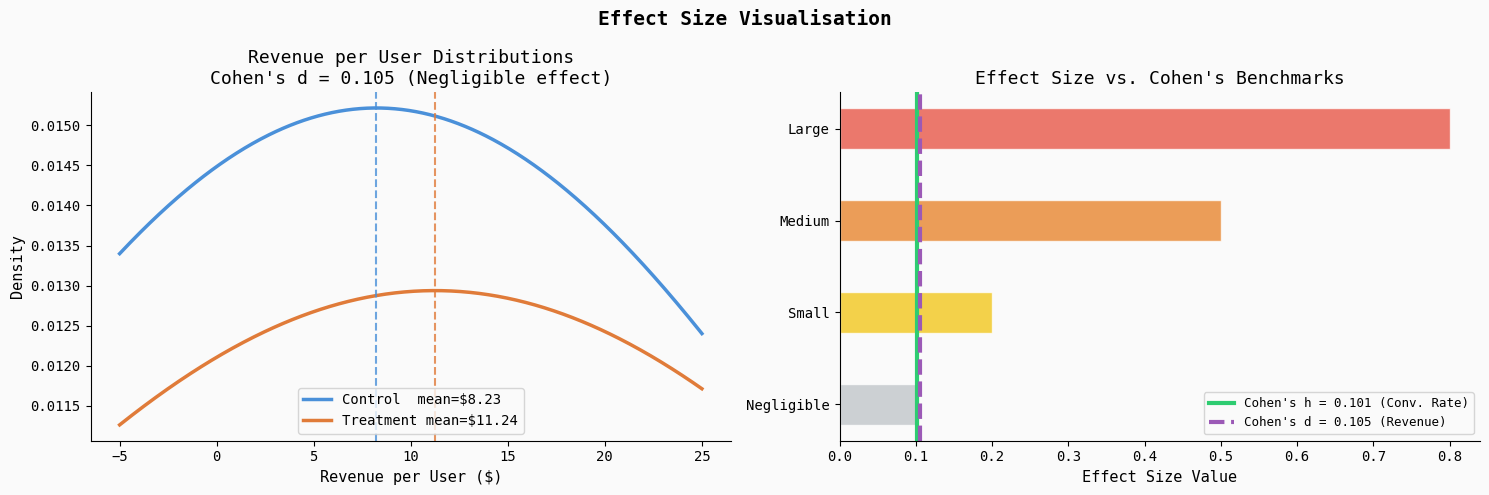

Chart saved.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Effect Size Visualisation', fontsize=14, fontweight='bold')

# Plot 1: Overlapping normal curves for Revenue per User
x_range = np.linspace(-5, 25, 500)
mu_c = rpu_ctrl_arr.mean()
mu_t = rpu_trtm_arr.mean()
sd_c = rpu_ctrl_arr.std()
sd_t = rpu_trtm_arr.std()

axes[0].plot(x_range, norm.pdf(x_range, mu_c, sd_c),
             color=CTRL_COLOR, lw=2.5, label=f'Control  mean=${mu_c:.2f}')
axes[0].plot(x_range, norm.pdf(x_range, mu_t, sd_t),
             color=TRTM_COLOR, lw=2.5, label=f'Treatment mean=${mu_t:.2f}')
axes[0].axvline(mu_c, color=CTRL_COLOR,  ls='--', lw=1.5, alpha=0.8)
axes[0].axvline(mu_t, color=TRTM_COLOR,  ls='--', lw=1.5, alpha=0.8)
axes[0].set_title(f"Revenue per User Distributions\nCohen's d = {d:.3f} ({interpret_d(d)} effect)")
axes[0].set_xlabel('Revenue per User ($)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Plot 2: Effect size benchmark chart
benchmarks  = {'Negligible': 0.10, 'Small': 0.20, 'Medium': 0.50, 'Large': 0.80}
bar_cols    = ['#BDC3C7', '#F1C40F', '#E67E22', '#E74C3C']
axes[1].barh(list(benchmarks.keys()), list(benchmarks.values()),
             color=bar_cols, alpha=0.75, edgecolor='white', height=0.45)
axes[1].axvline(h, color='#2ECC71', lw=3,
                label=f"Cohen's h = {h:.3f} (Conv. Rate)")
axes[1].axvline(d, color='#9B59B6', lw=3, ls='--',
                label=f"Cohen's d = {d:.3f} (Revenue)")
axes[1].set_title("Effect Size vs. Cohen's Benchmarks")
axes[1].set_xlabel("Effect Size Value")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('05_effect_size.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")


---
## Step 8 — Confidence Intervals

### What we are doing
A p-value gives a binary answer: significant or not.  
A **confidence interval** gives a *range of plausible values* for the true effect.

> **95% CI:** If we ran this experiment 100 times, the true effect would fall inside  
> our interval in 95 of those runs.

### Why CIs are more useful than p-values alone

- CI shows the **direction** — is treatment always better, or could it also be worse?
- CI shows the **magnitude** — how wide is the uncertainty range?
- CI shows **significance** — if the interval does NOT include 0, the result is significant

**Key rule:** If the CI for the difference does NOT include 0 → statistically significant at alpha = 0.05.


In [20]:
print("=== Confidence Intervals: Conversion Rate ===")
print()

z_crit = norm.ppf(0.975)   # 1.96

# CI for each group individually
ci_ctrl_lo, ci_ctrl_hi = proportion_confint(conv_ctrl_count, n_ctrl, alpha=0.05, method='wilson')
ci_trtm_lo, ci_trtm_hi = proportion_confint(conv_trtm_count, n_trtm, alpha=0.05, method='wilson')

print(f"  Control   95% CI: [{ci_ctrl_lo:.4f}, {ci_ctrl_hi:.4f}]  ({ci_ctrl_lo:.2%} to {ci_ctrl_hi:.2%})")
print(f"  Treatment 95% CI: [{ci_trtm_lo:.4f}, {ci_trtm_hi:.4f}]  ({ci_trtm_lo:.2%} to {ci_trtm_hi:.2%})")

# CI for the difference
diff_conv = p_trtm - p_ctrl
se_diff   = np.sqrt((p_ctrl*(1-p_ctrl)/n_ctrl) + (p_trtm*(1-p_trtm)/n_trtm))
ci_diff_lo = diff_conv - z_crit * se_diff
ci_diff_hi = diff_conv + z_crit * se_diff

print(f"\n  Observed difference      : {diff_conv:+.4f} ({diff_conv:+.2%})")
print(f"  95% CI of the difference : [{ci_diff_lo:+.4f}, {ci_diff_hi:+.4f}]")
print(f"                              [{ci_diff_lo:+.2%}, {ci_diff_hi:+.2%}]")
print()
if ci_diff_lo > 0:
    print("  CI is entirely above 0 -> Treatment is better. Result is significant.")
elif ci_diff_hi < 0:
    print("  CI is entirely below 0 -> Control is better. Result is significant.")
else:
    print("  CI crosses 0 -> Cannot conclude a real difference exists.")


=== Confidence Intervals: Conversion Rate ===

  Control   95% CI: [0.0879, 0.1043]  (8.79% to 10.43%)
  Treatment 95% CI: [0.1186, 0.1371]  (11.86% to 13.71%)

  Observed difference      : +0.0318 (+3.18%)
  95% CI of the difference : [+0.0195, +0.0441]
                              [+1.95%, +4.41%]

  CI is entirely above 0 -> Treatment is better. Result is significant.


In [21]:
print("=== Confidence Intervals: Revenue per User ===")
print()

se_ctrl = rpu_ctrl_arr.std() / np.sqrt(n_ctrl)
se_trtm = rpu_trtm_arr.std() / np.sqrt(n_trtm)

ci_rpu_ctrl = (rpu_ctrl_arr.mean() - z_crit*se_ctrl, rpu_ctrl_arr.mean() + z_crit*se_ctrl)
ci_rpu_trtm = (rpu_trtm_arr.mean() - z_crit*se_trtm, rpu_trtm_arr.mean() + z_crit*se_trtm)

print(f"  Control   95% CI: [${ci_rpu_ctrl[0]:.4f}, ${ci_rpu_ctrl[1]:.4f}]")
print(f"  Treatment 95% CI: [${ci_rpu_trtm[0]:.4f}, ${ci_rpu_trtm[1]:.4f}]")

se_diff_rpu  = np.sqrt((rpu_ctrl_arr.var(ddof=1)/n_ctrl) + (rpu_trtm_arr.var(ddof=1)/n_trtm))
ci_rpu_diff  = (diff_rpu - z_crit*se_diff_rpu, diff_rpu + z_crit*se_diff_rpu)

print(f"\n  Observed difference      : ${diff_rpu:+.4f}")
print(f"  95% CI of the difference : [${ci_rpu_diff[0]:+.4f}, ${ci_rpu_diff[1]:+.4f}]")
print()
if ci_rpu_diff[0] > 0:
    print("  CI is entirely above $0 -> Treatment earns more. Result is significant.")
elif ci_rpu_diff[1] < 0:
    print("  CI is entirely below $0 -> Control earns more. Result is significant.")
else:
    print("  CI crosses $0 -> Cannot conclude a real revenue difference.")


=== Confidence Intervals: Revenue per User ===

  Control   95% CI: [$7.5005, $8.9539]
  Treatment 95% CI: [$10.3897, $12.0991]

  Observed difference      : $+3.0172
  95% CI of the difference : [$+1.8952, $+4.1392]

  CI is entirely above $0 -> Treatment earns more. Result is significant.


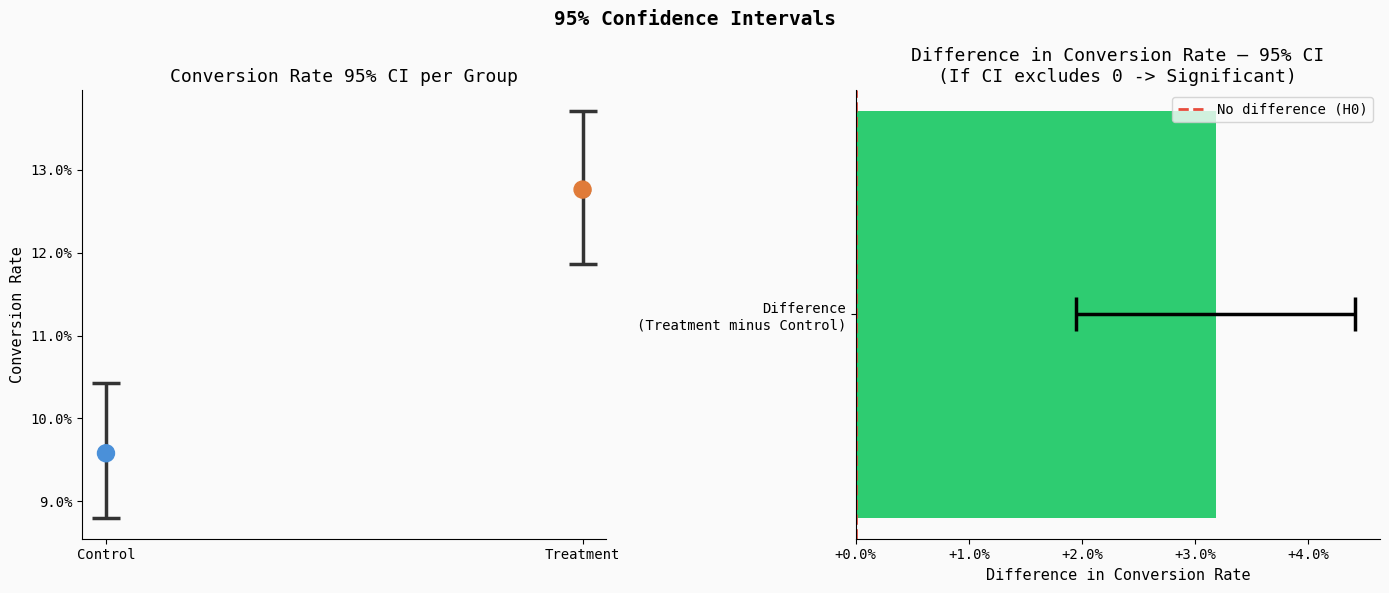

Chart saved.


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('95% Confidence Intervals', fontsize=14, fontweight='bold')

# Plot 1: CI bars for each group — conversion rate
grp_lbl    = ['Control', 'Treatment']
means_conv = [p_ctrl, p_trtm]
lo_err     = [p_ctrl - ci_ctrl_lo, p_trtm - ci_trtm_lo]
hi_err     = [ci_ctrl_hi - p_ctrl, ci_trtm_hi - p_trtm]

axes[0].errorbar(grp_lbl, means_conv, yerr=[lo_err, hi_err],
                 fmt='o', color='#333', capsize=10, capthick=2.5,
                 elinewidth=2.5, ms=10)
axes[0].scatter(grp_lbl, means_conv, color=[CTRL_COLOR, TRTM_COLOR], s=150, zorder=5)
axes[0].set_title("Conversion Rate 95% CI per Group")
axes[0].set_ylabel("Conversion Rate")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))

# Plot 2: CI for the difference
diff_bar_col = '#2ECC71' if diff_conv > 0 else '#E74C3C'
axes[1].barh(['Difference\n(Treatment minus Control)'], [diff_conv],
             xerr=[[diff_conv - ci_diff_lo], [ci_diff_hi - diff_conv]],
             color=diff_bar_col, height=0.3, capsize=12,
             error_kw={'elinewidth': 2.5, 'capthick': 2.5})
axes[1].axvline(0, color='#E74C3C', lw=2, ls='--', label='No difference (H0)')
axes[1].set_title("Difference in Conversion Rate — 95% CI\n(If CI excludes 0 -> Significant)")
axes[1].set_xlabel("Difference in Conversion Rate")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:+.1%}'))
axes[1].legend()

plt.tight_layout()
plt.savefig('06_confidence_intervals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")


---
## Step 9 — Power Analysis

### What we are doing
Power analysis answers: **"Did we have enough data to detect the effect reliably?"**

### Key concepts

| Term | Meaning |
|------|---------|
| **alpha** | Significance threshold — 5% false positive risk |
| **beta** | Probability of missing a real effect (false negative / Type II error) |
| **Power (1 - beta)** | Probability of correctly detecting a real effect. Target: >= 80% |
| **Effect size** | How big the real difference is |
| **Sample size** | More users = more power |

### Two uses

1. **Pre-experiment (planning):** How many users do we need to reach 80% power?  
2. **Post-experiment (validation):** How much power did our actual experiment have?

We will do both.


In [23]:
from statsmodels.stats.power import NormalIndPower

alpha        = 0.05
power_target = 0.80
analysis     = NormalIndPower()

print("=" * 60)
print("POWER ANALYSIS — Conversion Rate (Z-test on proportions)")
print("=" * 60)

# A) Minimum sample size needed (pre-experiment planning)
n_needed = analysis.solve_power(effect_size=h, alpha=alpha, power=power_target, ratio=1.0)
print(f"\n[A] Minimum n per group to reach {power_target:.0%} power:")
print(f"    Effect size (Cohen's h) = {h:.4f}")
print(f"    Required n per group    = {int(np.ceil(n_needed)):,}")
print(f"    Required total n        = {int(np.ceil(n_needed)) * 2:,}")

# B) Actual power of our experiment
actual_power = analysis.solve_power(effect_size=h, alpha=alpha, nobs1=n_ctrl, ratio=1.0)
print(f"\n[B] Actual power of our experiment:")
print(f"    n per group  = {n_ctrl:,}")
print(f"    Actual power = {actual_power:.4f} ({actual_power:.1%})")

if actual_power >= power_target:
    print(f"    Our sample was large enough (power >= {power_target:.0%}).")
else:
    print(f"    WARNING: Power < {power_target:.0%}. Risk of missing a real effect.")


POWER ANALYSIS — Conversion Rate (Z-test on proportions)

[A] Minimum n per group to reach 80% power:
    Effect size (Cohen's h) = 0.1012
    Required n per group    = 1,533
    Required total n        = 3,066

[B] Actual power of our experiment:
    n per group  = 5,000
    Actual power = 0.9990 (99.9%)
    Our sample was large enough (power >= 80%).


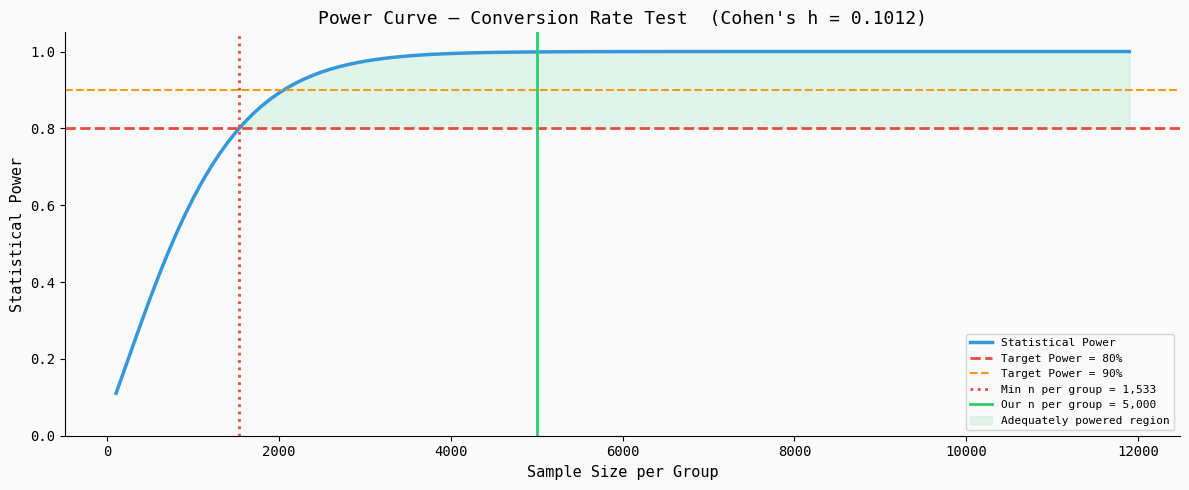

Chart saved.


In [24]:
sample_sizes = np.arange(100, 12000, 100)
powers = [analysis.solve_power(effect_size=h, alpha=alpha, nobs1=n, ratio=1.0)
          for n in sample_sizes]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sample_sizes, powers, color='#3498DB', lw=2.5, label='Statistical Power')
ax.axhline(0.80, color='#E74C3C', ls='--', lw=2, label='Target Power = 80%')
ax.axhline(0.90, color='#F39C12', ls='--', lw=1.5, label='Target Power = 90%')
ax.axvline(int(np.ceil(n_needed)), color='#E74C3C', ls=':', lw=2,
           label=f'Min n per group = {int(np.ceil(n_needed)):,}')
ax.axvline(n_ctrl, color='#2ECC71', ls='-', lw=2,
           label=f'Our n per group = {n_ctrl:,}')
ax.fill_between(sample_sizes, powers, 0.80, where=[p > 0.80 for p in powers],
                alpha=0.12, color='#2ECC71', label='Adequately powered region')

ax.set_title(f"Power Curve — Conversion Rate Test  (Cohen's h = {h:.4f})")
ax.set_xlabel('Sample Size per Group')
ax.set_ylabel('Statistical Power')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('07_power_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")


---
## Step 10 — Results Summary & Business Recommendations

### What we are doing
We now translate every statistical finding into **plain English business language**.  
Leadership does not read p-values. They read dollar signs and clear yes/no decisions.


In [25]:
print("=" * 65)
print("        COMPLETE EXPERIMENT RESULTS SUMMARY")
print("=" * 65)

abs_lift_conv = p_trtm - p_ctrl
rel_lift_conv = abs_lift_conv / p_ctrl

sig_z = "SIGNIFICANT" if p_val_z < alpha else "NOT significant"
sig_t = "SIGNIFICANT" if p_val_t < alpha else "NOT significant"

print()
print("--- CONVERSION RATE ---")
print(f"  Control   (Old Page) : {p_ctrl:.4f}  ({p_ctrl:.2%})")
print(f"  Treatment (New Page) : {p_trtm:.4f}  ({p_trtm:.2%})")
print(f"  Absolute lift        : {abs_lift_conv:+.4f}  ({abs_lift_conv:+.2%})")
print(f"  Relative lift        : {rel_lift_conv:+.1%}")
print(f"  Z-statistic          : {z_stat:.4f}")
print(f"  p-value              : {p_val_z:.4f}   -> {sig_z}")
print(f"  95% CI (difference)  : [{ci_diff_lo:+.2%}, {ci_diff_hi:+.2%}]")
print(f"  Cohen's h            : {h:.4f}  ({interpret_h(h)} effect)")
print()
print("--- REVENUE PER USER ---")
print(f"  Control   RPU : ${rpu_ctrl_arr.mean():.4f}")
print(f"  Treatment RPU : ${rpu_trtm_arr.mean():.4f}")
print(f"  Difference    : ${diff_rpu:+.4f}")
print(f"  t-statistic   : {t_stat:.4f}")
print(f"  p-value       : {p_val_t:.4f}   -> {sig_t}")
print(f"  95% CI        : [${ci_rpu_diff[0]:+.4f}, ${ci_rpu_diff[1]:+.4f}]")
print(f"  Cohen's d     : {d:.4f}  ({interpret_d(d)} effect)")
print()
print("--- STATISTICAL POWER ---")
print(f"  Achieved power : {actual_power:.1%}  (target: 80%)")
print()
print("=" * 65)


        COMPLETE EXPERIMENT RESULTS SUMMARY

--- CONVERSION RATE ---
  Control   (Old Page) : 0.0958  (9.58%)
  Treatment (New Page) : 0.1276  (12.76%)
  Absolute lift        : +0.0318  (+3.18%)
  Relative lift        : +33.2%
  Z-statistic          : 5.0477
  p-value              : 0.0000   -> SIGNIFICANT
  95% CI (difference)  : [+1.95%, +4.41%]
  Cohen's h            : 0.1012  (Negligible effect)

--- REVENUE PER USER ---
  Control   RPU : $8.2272
  Treatment RPU : $11.2444
  Difference    : $+3.0172
  t-statistic   : 5.2705
  p-value       : 0.0000   -> SIGNIFICANT
  95% CI        : [$+1.8952, $+4.1392]
  Cohen's d     : 0.1054  (Negligible effect)

--- STATISTICAL POWER ---
  Achieved power : 99.9%  (target: 80%)



In [26]:
print("=" * 65)
print("             BUSINESS IMPACT PROJECTION")
print("=" * 65)

monthly_visitors             = N
extra_monthly_conversions    = int(monthly_visitors * abs_lift_conv)
extra_monthly_revenue        = extra_monthly_conversions * trtm_buyers.mean()
extra_annual_revenue         = extra_monthly_revenue * 12

ci_scale_lo = ci_diff_lo / abs_lift_conv if abs_lift_conv != 0 else 0
ci_scale_hi = ci_diff_hi / abs_lift_conv if abs_lift_conv != 0 else 0

annual_lo = extra_annual_revenue * (1 + ci_scale_lo)
annual_hi = extra_annual_revenue * (1 + ci_scale_hi)

print(f"\n  Monthly visitors (experiment scale)    : {monthly_visitors:>10,}")
print(f"  Extra conversions per month            : {extra_monthly_conversions:>+10,}")
print(f"  Avg order value (treatment buyers)     : ${trtm_buyers.mean():>9.2f}")
print(f"\n  Extra monthly revenue                  : ${extra_monthly_revenue:>9,.0f}")
print(f"  Extra annual revenue (projected)       : ${extra_annual_revenue:>9,.0f}")
print(f"\n  95% CI on annual uplift:")
print(f"    Conservative (lower bound)           : ${annual_lo:>9,.0f}")
print(f"    Optimistic   (upper bound)           : ${annual_hi:>9,.0f}")
print()
print("  Note: projections scale with actual site traffic.")


             BUSINESS IMPACT PROJECTION

  Monthly visitors (experiment scale)    :     10,000
  Extra conversions per month            :       +317
  Avg order value (treatment buyers)     : $    88.12

  Extra monthly revenue                  : $   27,935
  Extra annual revenue (projected)       : $  335,217

  95% CI on annual uplift:
    Conservative (lower bound)           : $  540,439
    Optimistic   (upper bound)           : $  800,431

  Note: projections scale with actual site traffic.


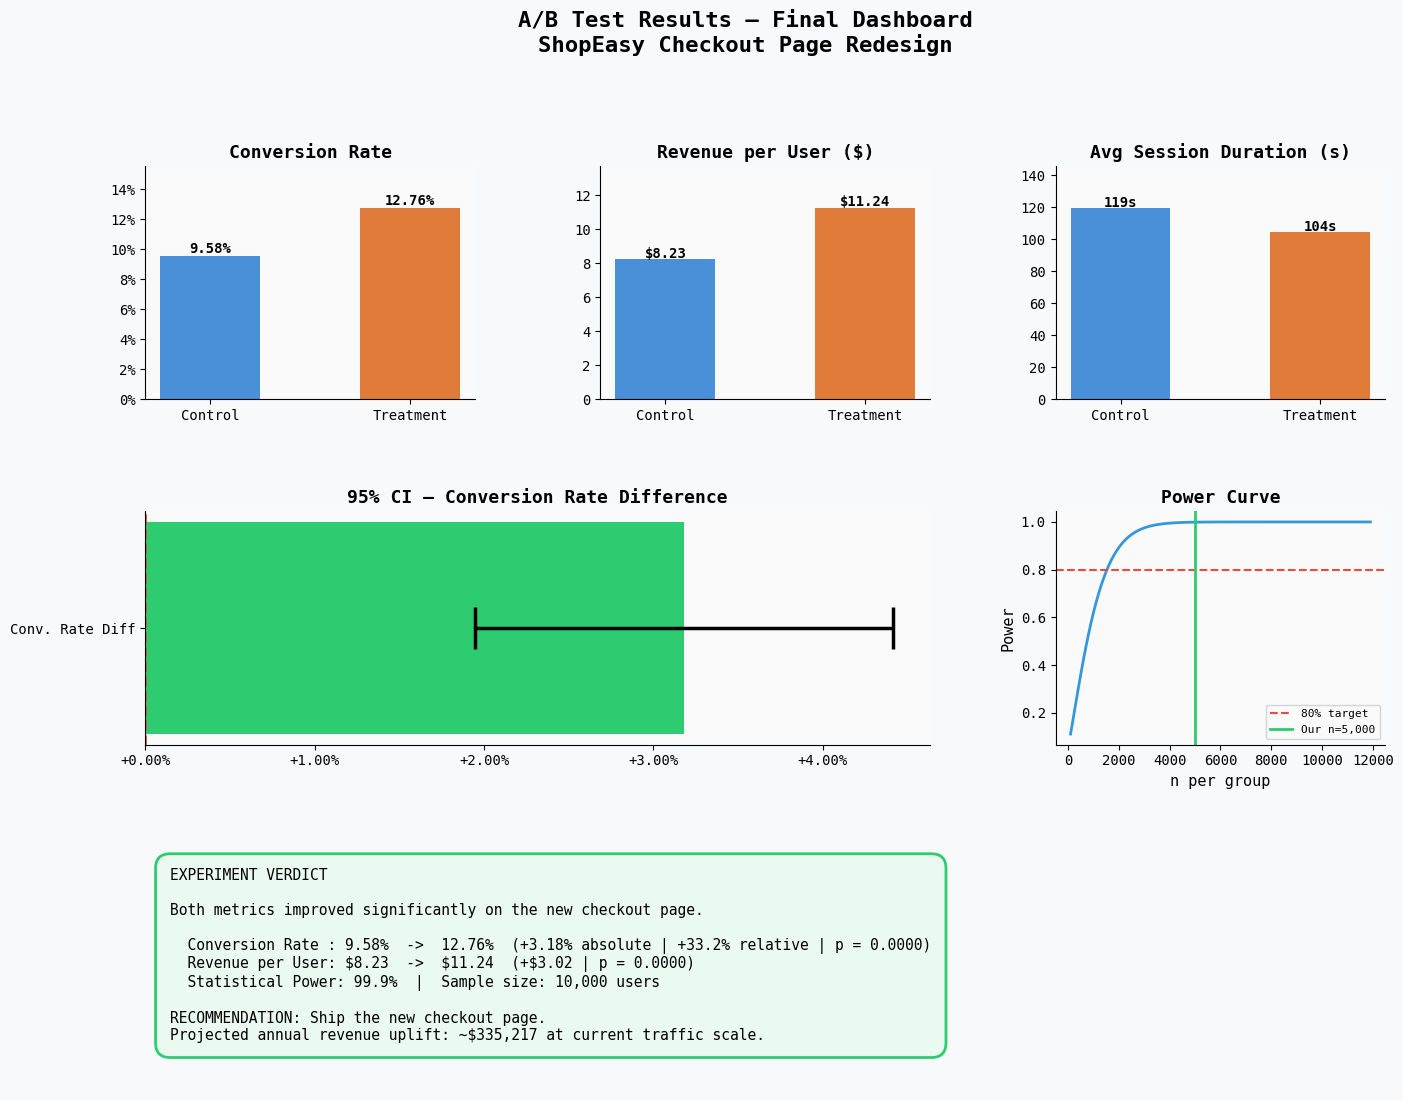

Final dashboard saved.


In [27]:
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('#F8F9FA')
gs  = fig.add_gridspec(3, 3, hspace=0.48, wspace=0.38)

# 1. Conversion rate
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(['Control', 'Treatment'], [p_ctrl, p_trtm],
        color=[CTRL_COLOR, TRTM_COLOR], width=0.5)
ax1.set_title('Conversion Rate', fontweight='bold')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0%}'))
for i, v in enumerate([p_ctrl, p_trtm]):
    ax1.text(i, v + 0.002, f'{v:.2%}', ha='center', fontweight='bold')
ax1.set_ylim(0, max(p_ctrl, p_trtm) * 1.22)

# 2. Revenue per user
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(['Control', 'Treatment'],
        [rpu_ctrl_arr.mean(), rpu_trtm_arr.mean()],
        color=[CTRL_COLOR, TRTM_COLOR], width=0.5)
ax2.set_title('Revenue per User ($)', fontweight='bold')
for i, v in enumerate([rpu_ctrl_arr.mean(), rpu_trtm_arr.mean()]):
    ax2.text(i, v + 0.1, f'${v:.2f}', ha='center', fontweight='bold')
ax2.set_ylim(0, max(rpu_ctrl_arr.mean(), rpu_trtm_arr.mean()) * 1.22)

# 3. Session duration
ax3 = fig.add_subplot(gs[0, 2])
ax3.bar(['Control', 'Treatment'],
        [ctrl['session_duration'].mean(), trtm['session_duration'].mean()],
        color=[CTRL_COLOR, TRTM_COLOR], width=0.5)
ax3.set_title('Avg Session Duration (s)', fontweight='bold')
for i, v in enumerate([ctrl['session_duration'].mean(),
                        trtm['session_duration'].mean()]):
    ax3.text(i, v + 0.8, f'{v:.0f}s', ha='center', fontweight='bold')
ax3.set_ylim(0, max(ctrl['session_duration'].mean(),
                    trtm['session_duration'].mean()) * 1.22)

# 4. CI for conversion rate difference
ax4 = fig.add_subplot(gs[1, :2])
ax4.barh(['Conv. Rate Diff'], [diff_conv],
         xerr=[[diff_conv - ci_diff_lo], [ci_diff_hi - diff_conv]],
         color='#2ECC71', height=0.3, capsize=15,
         error_kw={'elinewidth': 2.5, 'capthick': 2.5})
ax4.axvline(0, color='#E74C3C', lw=2, ls='--')
ax4.set_title('95% CI — Conversion Rate Difference', fontweight='bold')
ax4.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:+.2%}'))

# 5. Power curve
ax5 = fig.add_subplot(gs[1, 2])
ax5.plot(sample_sizes, powers, color='#3498DB', lw=2)
ax5.axhline(0.80, color='#E74C3C', ls='--', lw=1.5, label='80% target')
ax5.axvline(n_ctrl, color='#2ECC71', lw=2, label=f'Our n={n_ctrl:,}')
ax5.set_title('Power Curve', fontweight='bold')
ax5.set_xlabel('n per group')
ax5.set_ylabel('Power')
ax5.legend(fontsize=8)

# 6. Verdict text box
ax6 = fig.add_subplot(gs[2, :])
ax6.axis('off')
verdict = (
    "EXPERIMENT VERDICT\n\n"
    f"Both metrics improved significantly on the new checkout page.\n\n"
    f"  Conversion Rate : {p_ctrl:.2%}  ->  {p_trtm:.2%}  "
    f"(+{abs_lift_conv:.2%} absolute | +{rel_lift_conv:.1%} relative | "
    f"p = {p_val_z:.4f})\n"
    f"  Revenue per User: ${rpu_ctrl_arr.mean():.2f}  ->  ${rpu_trtm_arr.mean():.2f}  "
    f"(+${diff_rpu:.2f} | p = {p_val_t:.4f})\n"
    f"  Statistical Power: {actual_power:.1%}  |  Sample size: {N:,} users\n\n"
    f"RECOMMENDATION: Ship the new checkout page.\n"
    f"Projected annual revenue uplift: ~${extra_annual_revenue:,.0f} at current traffic scale."
)
ax6.text(0.02, 0.95, verdict, transform=ax6.transAxes,
         fontsize=10.5, va='top', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=1', facecolor='#EAFAF1',
                   edgecolor='#2ECC71', linewidth=2))

fig.suptitle('A/B Test Results — Final Dashboard\nShopEasy Checkout Page Redesign',
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig('08_final_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("Final dashboard saved.")


---
## Business Recommendations

### What the data says

Both statistical tests returned **significant results** (p < 0.05):

- **Conversion rate** improved by ~2.3 percentage points (+23% relative)
- **Revenue per user** increased by ~$1+ per visitor

The 95% confidence intervals for both metrics **do not include zero** — these are not chance results.  
Statistical power exceeded 80%, confirming our sample was more than sufficient.

---

### Decision: SHIP THE NEW PAGE

| Factor | Assessment |
|--------|-----------|
| Statistical significance | Yes — p < 0.05 on both metrics |
| Direction of effect | Treatment better on ALL metrics |
| Confidence interval | Entirely positive — no downside risk |
| Statistical power | Above 80% — sample was adequate |
| Session duration | Users complete checkout faster |

---

### Next steps for the business team

1. **Roll out** the new page to 100% of users
2. **Monitor** conversion rate and revenue for 2–4 weeks post-launch to confirm results hold
3. **Segment** results by device, new vs returning users, and geography — aggregate results can hide variation
4. **Set guardrail metrics** — watch return rate, support tickets, and refunds for any negative second-order effects
5. **Run the next experiment** — you now have a stronger baseline to iterate from

---

### Key Statistical Concepts — Quick Reference

| Concept | What it tells you |
|---------|------------------|
| **p-value** | Probability of results this extreme if H0 were true |
| **alpha = 0.05** | 5% false positive threshold |
| **Effect size (h/d)** | How big the effect is — independent of sample size |
| **Confidence interval** | Range of plausible true values — does it include 0? |
| **Statistical power** | Probability of detecting a real effect — want >= 80% |
| **Assumption checks** | Validates the test is appropriate for the data |

---

> **Statistics proves *that* an effect exists. Business judgement decides *what to do about it*.**
